In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Question 1

1a

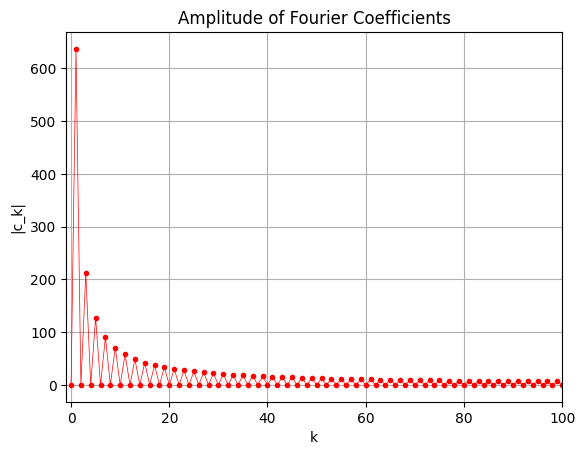

In [2]:
N = 1000
x = np.linspace(0, 1, N, endpoint=False)
y = np.where(x < 0.5, 1, -1)
c = np.fft.rfft(y)

plt.figure()
k = np.arange(N//2+1)
plt.plot(k, np.abs(c), 'ro-', markersize=3, linewidth=0.5)
plt.xlabel('k')
plt.ylabel('|c_k|')
plt.title('Amplitude of Fourier Coefficients')
plt.grid(True)
plt.xlim(-1,100) 
plt.show()


1b

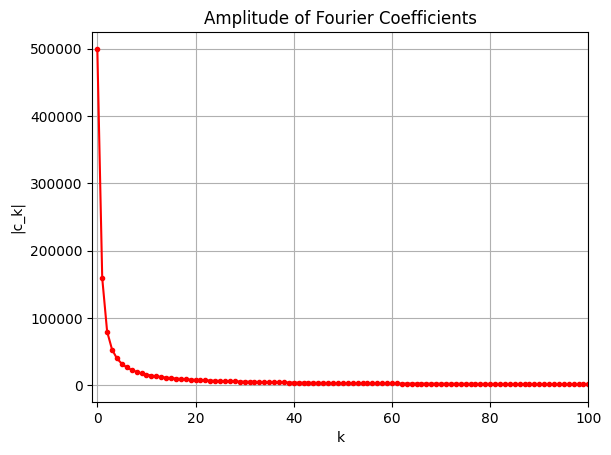

In [3]:
N = 1000
y = np.zeros(N)
for i in range(N):
    y[i]= i
c = np.fft.rfft(y)
plt.figure()
k = np.arange(N//2+1)
plt.plot(k, np.abs(c), 'ro-',markersize=3)
plt.xlabel('k')
plt.ylabel('|c_k|')
plt.title('Amplitude of Fourier Coefficients')
plt.xlim(-1,100)
plt.grid(True)
plt.show()

1c

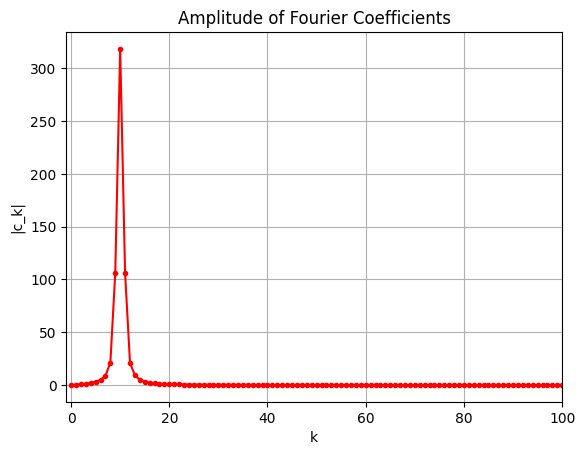

In [4]:
N = 1000
y = np.zeros(N)
for i in range(N):
    y[i]= np.sin(np.pi*i/N)*np.sin(20*np.pi*i/N)
c = np.fft.rfft(y)
plt.figure()
k = np.arange(N//2+1)
plt.plot(k, np.abs(c), 'ro-',markersize=3)
plt.xlabel('k')
plt.ylabel('|c_k|')
plt.title('Amplitude of Fourier Coefficients')
plt.xlim(-1,100)
plt.grid(True)
plt.show()

# Question 2

2a

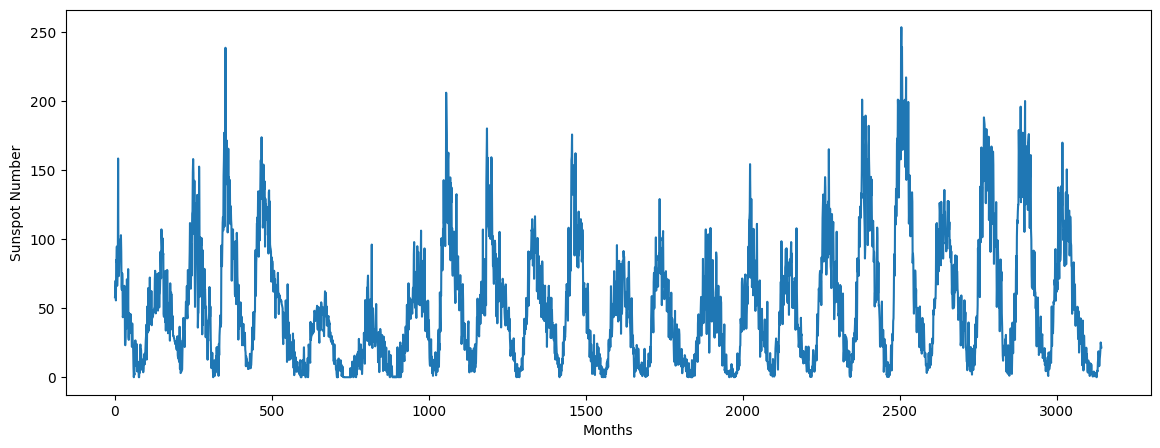

In [25]:
dat_spots = pd.read_csv('sunspots.txt',sep = '\t', header = None, names = ['month', 'sunspots'])
months = dat_spots.iloc[:,0]
sunspots = dat_spots.iloc[:,1]
plt.figure(figsize= (14,5))
plt.plot(months,sunspots)
plt.xlabel("Months")
plt.ylabel("Sunspot Number")
plt.show()

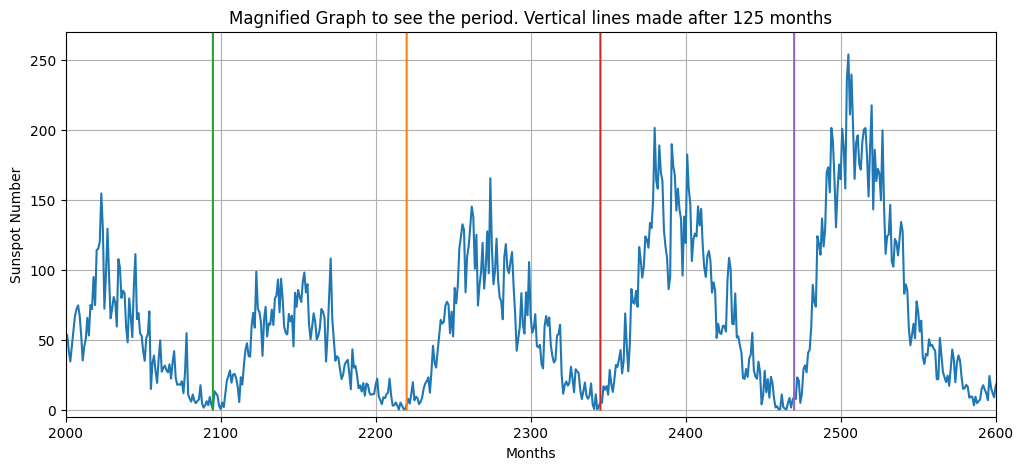

In [27]:
a = np.ones(len(sunspots))
x1 = 2220*a
x2 = 2095*a
x3 = 2345*a
x4 = 2470*a
y = np.arange(len(sunspots))*2*(max(sunspots))/len(sunspots)
plt.figure(figsize= (12,5))
plt.plot(months,sunspots)
plt.plot(x1,y)
plt.plot(x2,y)
plt.plot(x3,y)
plt.plot(x4,y)
plt.ylim(-5,270)
plt.xlabel("Months")
plt.ylabel("Sunspot Number")
plt.grid()
plt.title('Magnified Graph to see the period. Vertical lines made after 125 months')
plt.xlim(2000,2600)
plt.show()


So we see that cycle has a period of approximately **125 months**

2b

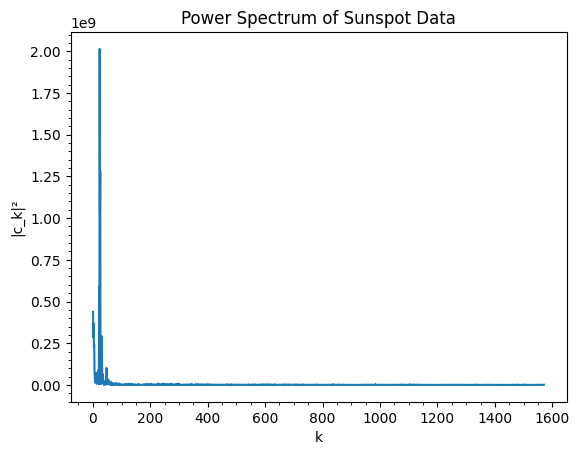

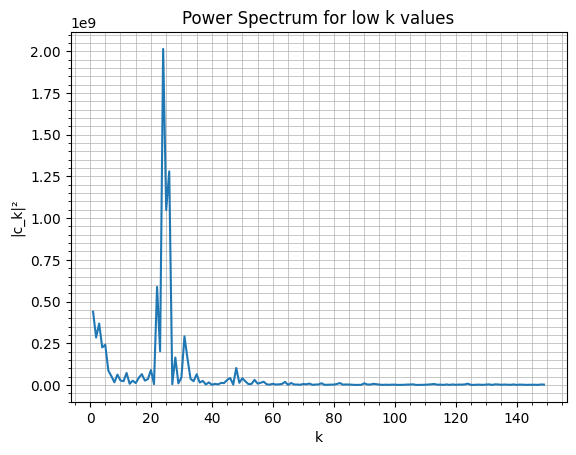

In [30]:
c = np.fft.rfft(sunspots)
power_spectrum = np.abs(c)**2
k_vals = np.arange(len(power_spectrum//2+1))[1:]
plot_vals = power_spectrum[1:]

plt.figure()
plt.plot(k_vals, plot_vals)
plt.minorticks_on() 
plt.xlabel('k')
plt.ylabel('|c_k|²')
plt.title('Power Spectrum of Sunspot Data')
plt.show()

k_vals1 = np.arange(1,150)
plot_vals1 = power_spectrum[1:150]


plt.figure()
plt.plot(k_vals1, plot_vals1)
plt.minorticks_on() 
plt.xlabel('k')
plt.ylabel('|c_k|²')
plt.title('Power Spectrum for low k values')
plt.grid(visible=True, which='both', linestyle='-', linewidth=0.5)
plt.show()

In [32]:
largestelement = 0
kvalue = 0
for key,vals in enumerate(power_spectrum[1:]):
    if vals>largestelement:
        largestelement = vals
        kvalue = key+1

print(f"Maxima at k = {kvalue}")
datasize = len(sunspots)
N = len(power_spectrum)
size = 2*N/kvalue
print(f"Period of most dominant wave is {size:.2f} months")
print(f"This is close to our earlier observed value of 125 months")


Maxima at k = 24
Period of most dominant wave is 131.00 months
This is close to our earlier observed value of 125 months


# Problem 3

3a

In [47]:
def DFT(filename): 
    file = filename+'.txt'
    waveform = pd.read_csv(file,sep='\t',header=None).iloc[:,0]
    N = len(waveform)
    xvals = np.arange(0,N)
    plt.figure(figsize=(20,5))
    plt.plot(xvals,waveform)
    plt.xlabel('Sample')
    plt.title('Waveform of ' + filename)
    plt.show()
    
    c = np.fft.rfft(waveform)
    abs_c = np.abs(c)
    c_vals = abs_c[1:10000]
    xplot = np.arange(1,10000)
    plt.figure(figsize=(12,5))
    plt.plot(xplot,c_vals)
    plt.xlabel('k')
    plt.ylabel('|c_k|')
    plt.title('First 10,000 fourier coefficients of ' + filename + ' waveform')
    plt.show()
    return waveform, abs_c


     

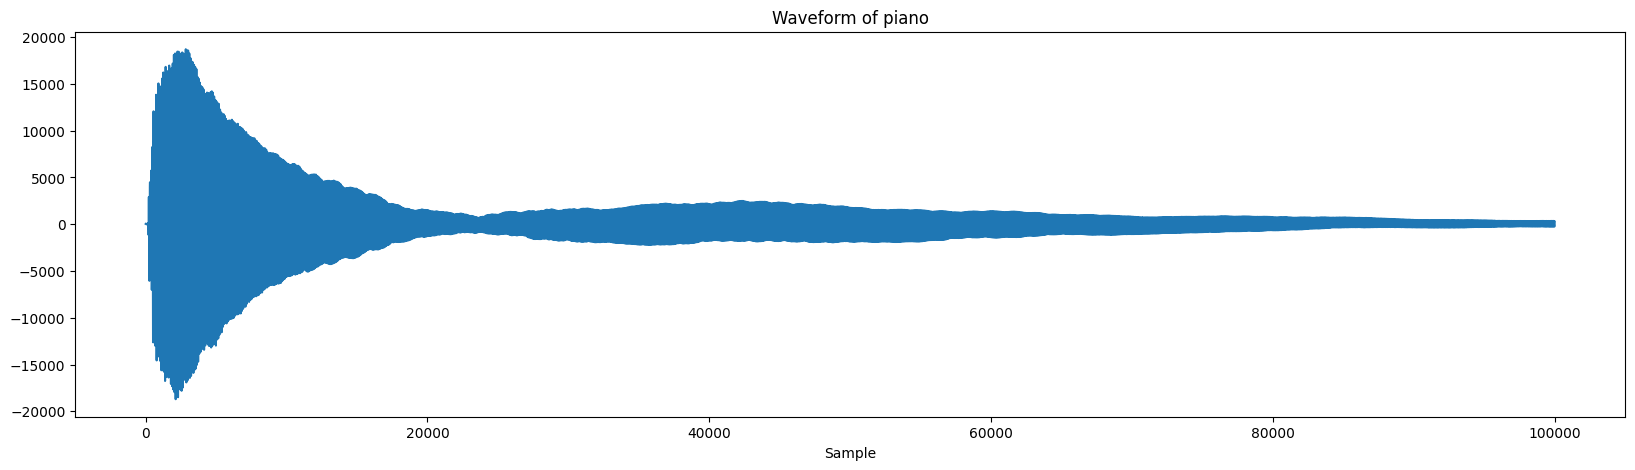

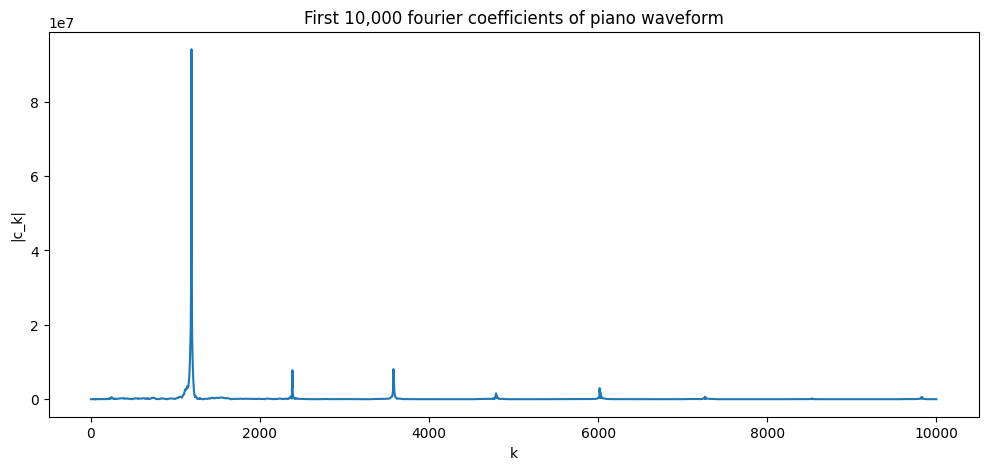

In [48]:
pianowaveform, pianoc = DFT('piano')

So from the fourier plot, we see that peaks are occuring after a fixed period. This tells us that a single note is being played.  
We see contributions from all harmonics of the fundamental frequency but the major dominant contribution is from the first harmonic itself.  
The second, thrid also have some contributions but it is very small (~10% of first harmonic). Then the next contribution is from 5th harmonic then 4th. After this there is almost no contribution from higher harmonics.  
Note that this feature of contributions in higher harmonics is a characterstic of the instrument being played.   
So we see that for piano, the fundamental frequency is the most dominant with minor constributions from 2nd,3rd and 5th harmonics.  

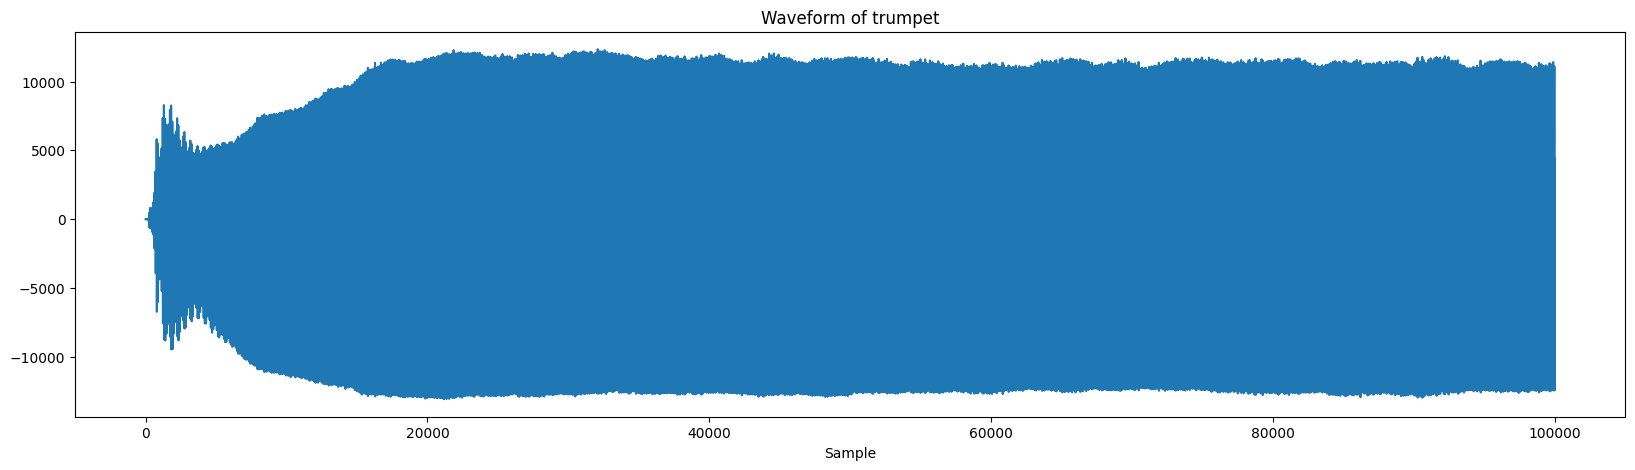

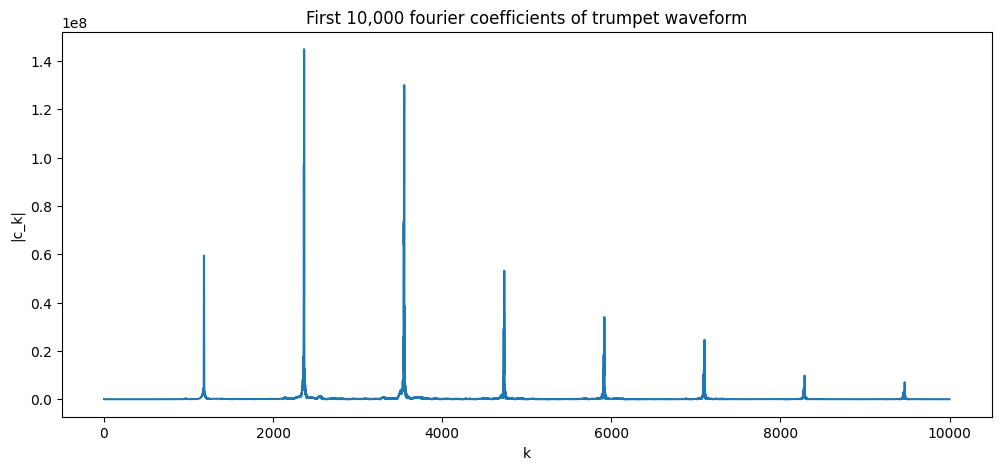

In [44]:
trumpetwaveform, trumpetc = DFT('trumpet')

From the above fourier plot, we see that the higher harmonics contrubute much more in case of trumphet than in the case of piano.  
Infact the highest contribution is from the second harmonic of the fundamental frequency, then the third, then the first. After this the the contribution decrease from 4th harmonic onwards.   
So in case of trumphet there are actually multiple frequencies being played (integer multiples of fundamental frequency) unlike in case of piano where major contribution is from a single frequency.

3b

In [54]:
largestelement = 0
kvalue = 0
for key,vals in enumerate(pianoc):
    if vals>largestelement:
        largestelement = vals
        kvalue = key

print(f'k with max contribution = {kvalue}')

Npiano = len(pianowaveform)
freqmax = 44100 * kvalue/Npiano
print(f'{freqmax} Hz')


k with max contribution = 1190
524.79 Hz


In [55]:
for key,vals in enumerate(trumpetc):
    if vals>largestelement:
        largestelement = vals
        kvalue = key

print(f'k with max contribution = {kvalue}')

Npiano = len(pianowaveform)
freqmax = 44100 * kvalue/Npiano
print(f'{freqmax} Hz')

k with max contribution = 2367
1043.847 Hz


So we see that the fundamental frequecny of the note is twice the frequency of middle C. Thus we conclude that both the instruments are playing **middle C**. 
In case of piano max contribution is from the fundamental frequency itself while in case of trumphet it is from second harmonic (first overtone)of the fundamental frequency.

# Problem 4

4a

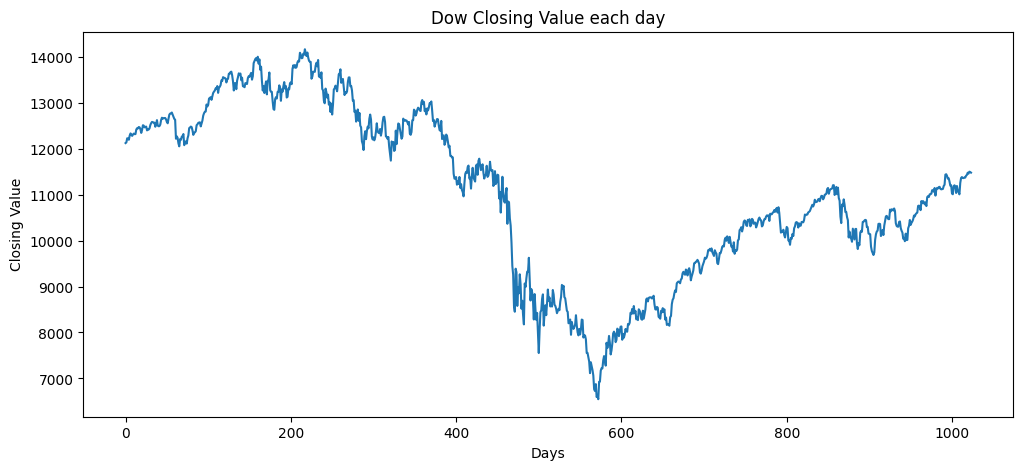

In [12]:
dowdata= pd.read_csv('dow.txt', sep='\t',header = None).iloc[:,0]
xvals = np.arange(len(dowdata))
plt.figure(figsize=(12,5))
plt.plot(xvals,dowdata)
plt.xlabel('Days')
plt.ylabel('Closing Value')
plt.title('Dow Closing Value each day')
plt.show()


4b

In [56]:
cdow = np.fft.rfft(dowdata)
cabsdow = np.abs(cdow)
k_vals = np.arange(0,len(cabsdow))

4c

In [58]:
M = len(cdow)
cdow_new = np.append(cdow[:M//10] ,np.zeros(9*M//10 + 1))
cdow_newabs = np.abs(cdow_new)

4d

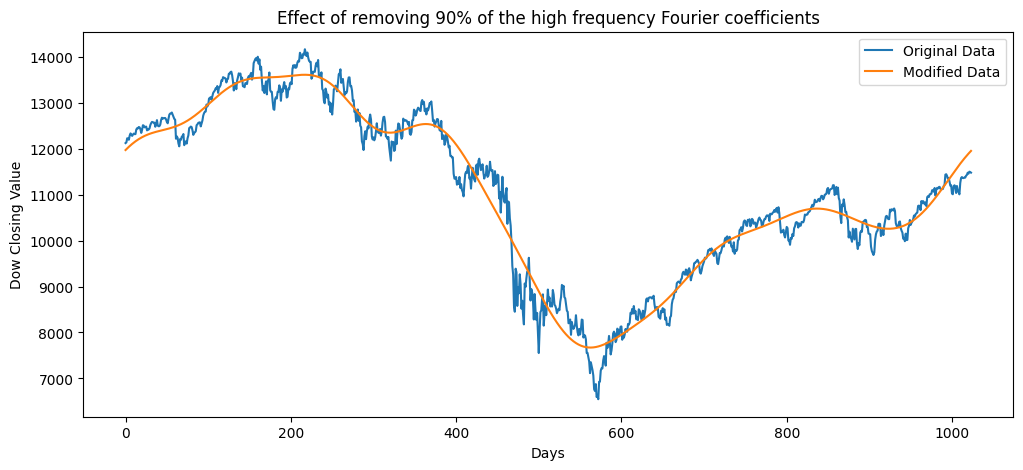

In [61]:
newdata = np.fft.irfft(cdow_new)
plt.figure(figsize= (12,5))
plt.plot(xvals,dowdata, label = 'Original Data' )
plt.plot(xvals,newdata, label = 'Modified Data')
plt.legend()
plt.xlabel('Days')
plt.ylabel('Dow Closing Value')
plt.title('Effect of removing 90% of the high frequency Fourier coefficients')
plt.show()

By zeroing out 90% of the high-frequency Fourier coefficients, we perform low-pass filtering. This removes rapid fluctuations and noise, leaving only the smooth, long-term trends in the Dow Jones data. The filtered curve shows the overall market direction without the day-to-day volatility.

4e

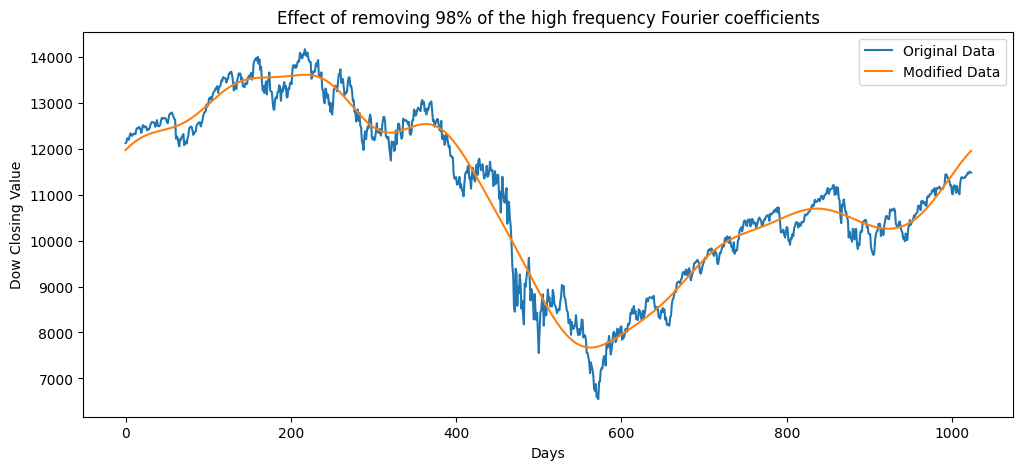

In [62]:
M = len(cdow)
cdow_new = np.append(cdow[:M//50] ,np.zeros(49*M//50 + 1))
cdow_newabs = np.abs(cdow_new)
newdata = np.fft.irfft(cdow_new)
plt.figure(figsize= (12,5))
plt.plot(xvals,dowdata, label = 'Original Data' )
plt.plot(xvals,newdata, label = 'Modified Data')
plt.legend()
plt.xlabel('Days')
plt.ylabel('Dow Closing Value')
plt.title('Effect of removing 98% of the high frequency Fourier coefficients')
plt.show()

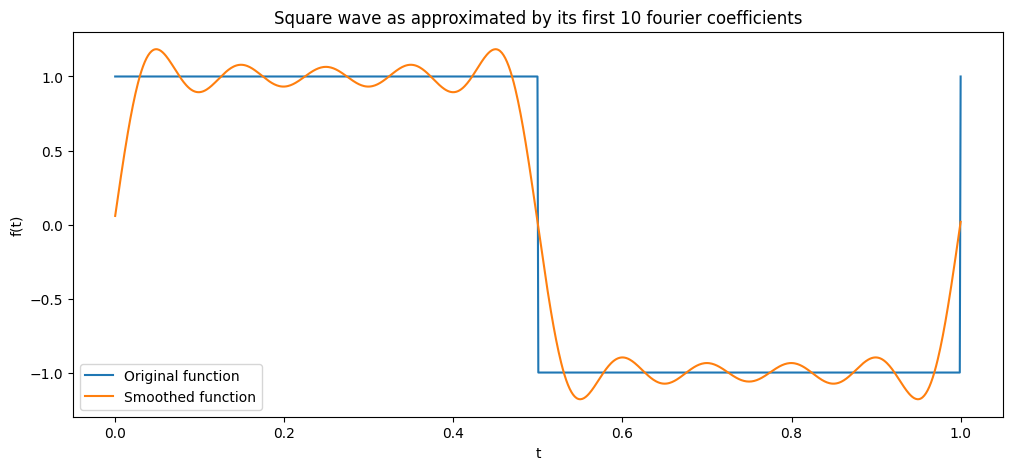

In [64]:
def f(t):
    k = 2*t
    r = 2* (k//2)
    if k - r < 1: # 2t is even
        return 1
    return -1

xvals = np.linspace(0, 1, 1000)
fvals = np.zeros(1000)
for i,x in enumerate(xvals):
    fvals[i] = f(x)

cvals = np.fft.rfft(fvals)
cvals_new = np.append(cvals[:10],np.zeros(len(cvals)-10))

newfunc = np.fft.irfft(cvals_new)
plt.figure(figsize=(12,5))
plt.plot(xvals,fvals,label = 'Original function')
plt.plot(xvals,newfunc,label = 'Smoothed function')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.legend()
plt.title('Square wave as approximated by its first 10 fourier coefficients')
plt.show()

The wiggles are due to **Gibbs phenomenon**. A square wave has sharp discontinuities that require infinite high-frequency Fourier components to represent exactly. By keeping only the first 10 coefficients, we're trying to approximate sharp jumps with smooth sine waves, which causes overshooting and oscillations (ringing) near the edges. 

# Problem 5

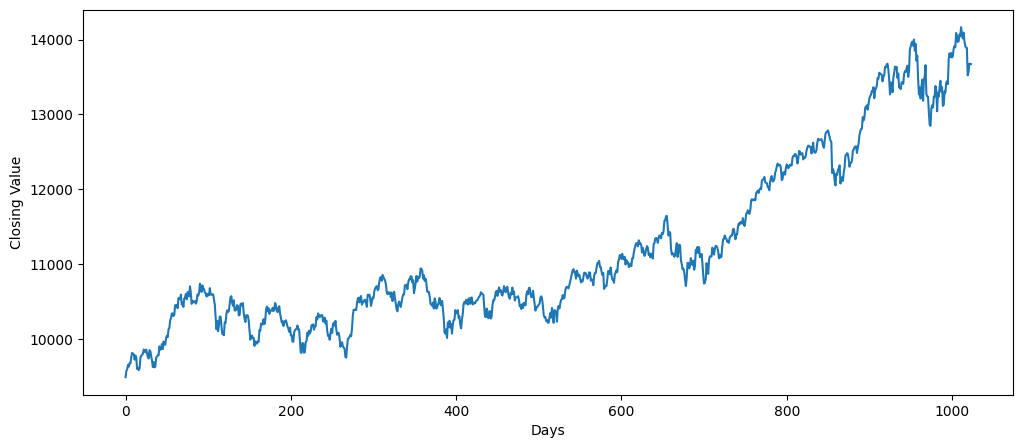

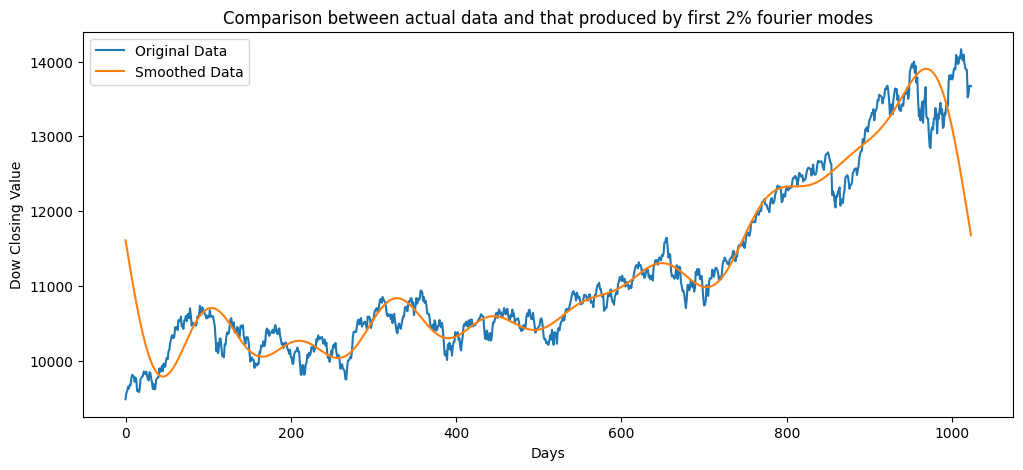

In [18]:
dowdata2= pd.read_csv('dow2.txt', sep='\t',header = None).iloc[:,0]
xvals2 = np.arange(len(dowdata2))
plt.figure(figsize=(12,5))
plt.plot(xvals2,dowdata2)
plt.xlabel('Days')
plt.ylabel('Closing Value')
plt.show()

cdow2 = np.fft.rfft(dowdata2)
cabsdow2 = np.abs(cdow2)
k_vals2 = np.arange(0,len(cabsdow2))


M = len(cdow2)
cdow_new2 = np.append(cdow2[:M//50] ,np.zeros(49*M//50 + 1))
cdow_newabs2 = np.abs(cdow_new2)
newdata2 = np.fft.irfft(cdow_new2)
plt.figure(figsize= (12,5))
plt.plot(xvals2,dowdata2, label = 'Original Data' )
plt.plot(xvals2,newdata2, label = 'Smoothed Data')
plt.legend()
plt.xlabel('Days')
plt.ylabel('Dow Closing Value')
plt.title('Comparison between actual data and that produced by first 2% fourier modes')
plt.show()

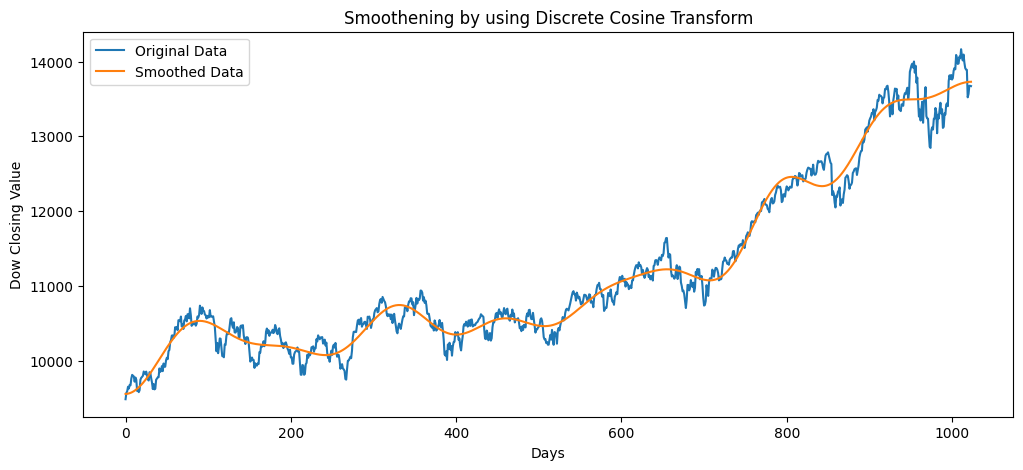

In [19]:
from scipy.fft import dct,idct
cdow2 = dct(dowdata2)
cabsdow2 = np.abs(cdow2)
k_vals2 = np.arange(0,len(cabsdow2))

M = len(cdow2)
cdow_new2 = np.append(cdow2[:M//50] ,np.zeros(49*M//50 + 1))
cdow_newabs2 = np.abs(cdow_new2)
newdata2 = idct(cdow_new2)
plt.figure(figsize= (12,5))
plt.plot(xvals2,dowdata2, label = 'Original Data' )
plt.plot(xvals2,newdata2, label = 'Smoothed Data')
plt.legend()
plt.xlabel('Days')
plt.ylabel('Dow Closing Value')
plt.title('Smoothening by using Discrete Cosine Transform')
plt.show()

# Problem 6

In [65]:
def fft(y):
    N = len(y)
    if N == 1:
        return np.array([y[0]], dtype=complex)
    
    y_even = y[0::2]  
    y_odd = y[1::2]  
    E_k = fft(y_even)  
    O_k = fft(y_odd)   
    k = np.arange(N // 2)
    twiddle = np.exp(-2j * np.pi * k / N)
    c = np.zeros(N, dtype=complex)
    c[:N//2] = E_k + twiddle * O_k
    c[N//2:] = E_k - twiddle * O_k
    return c

pitchdata = pd.read_csv('pitch.txt', sep='\t', header=None).iloc[:,0].values
numpyfft = np.fft.fft(pitchdata)
myfft = fft(pitchdata)

print(f"Maximum difference: {np.max(np.abs(numpyfft - myfft))}")
print('As the maximum difference is so small, we can safely say that our implementation is correct')

Maximum difference: 3.369651068788749e-13
As the maximum difference is so small, we can safely say that our implementation is correct


# Problem 7

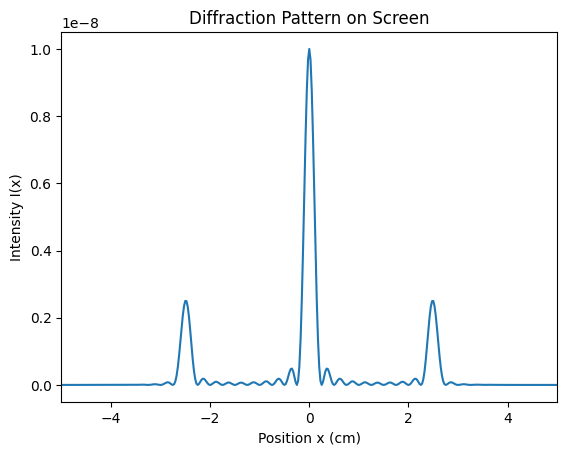

In [71]:
# Parameters
wavelength = 500e-9 
f = 1.0  
w = 200e-6  
W = 10 * w  
slit_width = 20e-6  
alpha = np.pi / slit_width
N = 100000

u = np.linspace(-W/2, W/2, N)
q_u = np.zeros(N)
mask = np.abs(u) <= w/2
q_u[mask] = np.sin(alpha * u[mask])**2
c_k = np.fft.fft(q_u)
I_k = (W**2 / N**2) * np.abs(c_k)**2
k = np.arange(N)
x_k = (wavelength * f / W) * k
x_k = x_k - x_k[N//2]
I_k = np.fft.fftshift(I_k)
mask_plot = (x_k >= -0.05) & (x_k <= 0.05)

plt.figure()
plt.plot(x_k[mask_plot] * 100, I_k[mask_plot])
plt.xlabel('Position x (cm)')
plt.ylabel('Intensity I(x)')
plt.title('Diffraction Pattern on Screen')
plt.xlim(-5, 5)
plt.show()

This is the same graph we got in HW2 using numerical integration

# Problem 8

8a

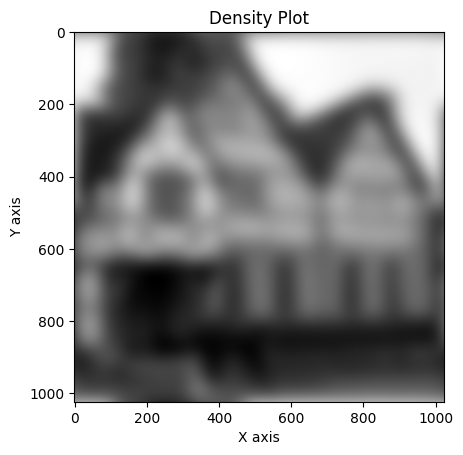

In [22]:
picture = pd.read_csv('blur.txt', sep=r'\s+', header=None).values
plt.figure()
plt.imshow(picture, cmap='gray', origin='upper')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.title('Density Plot')
plt.show()

8b

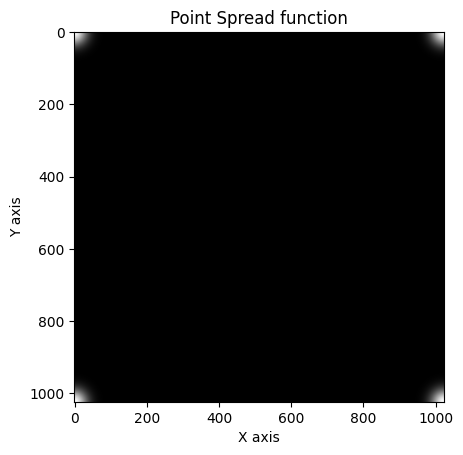

In [68]:
def f(x, y):
    sigma = 25
    return np.exp(-(x*x + y*y) / (2*sigma*sigma))

K, L = picture.shape
xvals = np.arange(K)
yvals = np.arange(L)
smear = np.zeros((K, L))

for x in xvals:
    for y in yvals:
        dx = min(abs(x - K//2), K - abs(x - K//2))
        dy = min(abs(y - L//2), L - abs(y - L//2))
        smear[x, y] = f(dx, dy)
smear = np.fft.ifftshift(smear)
plt.figure()
plt.imshow(smear, cmap='gray', origin='upper')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.title('Point Spread function')
plt.show()


8c

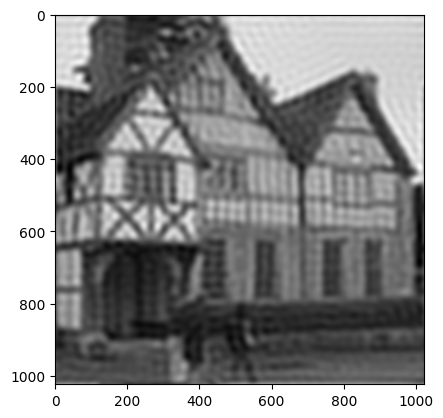

In [24]:
picture = pd.read_csv('blur.txt', sep=r'\s+', header=None).values

def f(x, y):
    sigma = 25
    return np.exp(-(x*x + y*y) / (2*sigma*sigma))

K, L = picture.shape
xvals = np.arange(K)
yvals = np.arange(L)
smear = np.zeros((K, L))

for x in xvals:
    for y in yvals:
        dx = min(abs(x - K//2), K - abs(x - K//2))
        dy = min(abs(y - L//2), L - abs(y - L//2))
        smear[x, y] = f(dx, dy)
smear = np.fft.ifftshift(smear)
b_tilda = np.fft.rfft2(picture)
f_tilda = np.fft.rfft2(smear)
K_fft, L_fft = b_tilda.shape
a_tilda = np.zeros((K_fft, L_fft), dtype=complex)
epsilon = 1e-3
for i in range(K_fft):
    for j in range(L_fft):
        if np.abs(f_tilda[i, j]) < epsilon:
            a_tilda[i, j] = b_tilda[i, j]
        else:
            a_tilda[i, j] = b_tilda[i, j] / f_tilda[i, j]
processedimage = np.fft.irfft2(a_tilda, s=(K, L))
plt.figure()
plt.imshow(processedimage, cmap='gray', origin='upper')
plt.show()

8d

The Gaussian blur acts as a low-pass filter that suppresses high-frequency components (fine details). In Fourier space, f̃(k) → 0 for high frequencies. When deblurring via division b̃/f̃, we must divide by near-zero values at high k, which amplifies noise enormously and creates artifacts. Frequencies where f̃(k) < ε are completely lost and cannot be recovered. Therefore, perfect deblurring is impossible as high-frequency detail is either destroyed by the blur or buried in noise when we try to recover it.